# VAE Portfolio Project - VaR Calculation

This notebook calculates Value at Risk (VaR) for the portfolio using VAE-generated scenarios.

In [1]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from var_calculator import VaRCalculator, PortfolioVaRAnalyzer
from utils import PortfolioConfig

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load configuration
config = PortfolioConfig()

# Load scenarios
scenarios = pd.read_csv('../results/scenarios.csv')
portfolio_returns = pd.read_csv('../results/portfolio_returns.csv')

print(f"Scenarios shape: {scenarios.shape}")
print(f"Portfolio returns shape: {portfolio_returns.shape}")

# Extract data
generated_scenarios = scenarios.values
generated_portfolio = portfolio_returns['generated'].values
historical_portfolio = portfolio_returns['historical'].values

Scenarios shape: (10000, 60)
Portfolio returns shape: (10000, 2)


## 2. Calculate VaR - Generated Scenarios

In [3]:
# Initialize calculator with generated portfolio returns
var_calc_generated = VaRCalculator(generated_portfolio, config.weights)

# Calculate VaR
var_summary_generated = var_calc_generated.var_summary(config.var_levels)

print("\n" + "="*70)
print("VaR CALCULATION - VAE GENERATED SCENARIOS")
print("="*70)
print(var_summary_generated.to_string())


VaR CALCULATION - VAE GENERATED SCENARIOS
  Confidence Level  Historical VaR  Parametric VaR      CVaR
0              95%       -0.014606       -0.013812 -0.021203
1              99%       -0.025292       -0.019601 -0.030960


## 3. Calculate VaR - Historical Data

In [4]:
# Load historical returns
import os
from data_loader import PortfolioDataLoader

historical_returns_path = '../data/returns.csv'
if os.path.exists(historical_returns_path):
    historical_returns = pd.read_csv(historical_returns_path, index_col=0, parse_dates=True)
    if list(historical_returns.columns) != list(config.indices):
        print('Historical returns do not match the current 60-asset configuration. Refreshing data from Yahoo Finance...')
        loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
        loader.fetch_data()
        historical_returns = loader.calculate_returns(method='log')
        historical_returns.to_csv(historical_returns_path, index=True)
else:
    print('No cached historical returns found. Refreshing data from Yahoo Finance...')
    loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
    loader.fetch_data()
    historical_returns = loader.calculate_returns(method='log')
    historical_returns.to_csv(historical_returns_path, index=True)

historical_returns_array = historical_returns.values

# Calculate portfolio returns
historical_weights_normalized = config.weights / config.weights.sum()
historical_portfolio_calc = np.dot(historical_returns_array, historical_weights_normalized)

# Initialize calculator
var_calc_historical = VaRCalculator(historical_portfolio_calc, config.weights)

# Calculate VaR
var_summary_historical = var_calc_historical.var_summary(config.var_levels)

print("\n" + "="*70)
print("VaR CALCULATION - HISTORICAL DATA")
print("="*70)
print(var_summary_historical.to_string())

Historical returns do not match the current 60-asset configuration. Refreshing data from Yahoo Finance...
Fetching data for 60 indices...
✓ Successfully loaded data. Shape: (4451, 60)
Returns shape: (4448, 60)
Mean returns:
Ticker
AGG        -0.000008
CL=F        0.000278
DIA         0.000365
DX-Y.NYB    0.000036
EEM         0.000271
EFA         0.000168
ES=F        0.000429
EWA         0.000147
EWC         0.000291
EWG         0.000212
EWH         0.000161
EWJ         0.000186
EWQ         0.000162
EWS         0.000170
EWU         0.000076
EWW         0.000290
FXI         0.000153
GC=F        0.000526
GLD         0.000504
HG=F        0.000337
IEF         0.000021
IVV         0.000428
IWM         0.000355
IYR         0.000137
KC=F        0.000259
LQD        -0.000004
NG=F       -0.000174
NQ=F        0.000674
QQQ         0.000671
SHY         0.000002
SPY         0.000427
TIP         0.000011
TLT        -0.000013
VOX         0.000301
VTI         0.000430
XLB         0.000294
XLE         0

## 4. Compare VaR Methods

In [5]:
# Create comparison table
comparison = pd.DataFrame({
    'Confidence': var_summary_generated['Confidence Level'],
    'Generated Historical': var_summary_generated['Historical VaR'],
    'Generated Parametric': var_summary_generated['Parametric VaR'],
    'Generated CVaR': var_summary_generated['CVaR'],
    'Historical Historical': var_summary_historical['Historical VaR'],
    'Historical Parametric': var_summary_historical['Parametric VaR'],
    'Historical CVaR': var_summary_historical['CVaR']
})

print("\n" + "="*100)
print("VaR COMPARISON: GENERATED vs HISTORICAL")
print("="*100)
print(comparison.to_string())

# Calculate differences
print("\n" + "="*100)
print("DIFFERENCES (Generated - Historical)")
print("="*100)
diff = comparison.copy()
for col in ['Generated Historical', 'Generated Parametric', 'Generated CVaR']:
    hist_col = col.replace('Generated ', 'Historical ')
    diff[col] = comparison[col] - comparison[hist_col]
print(diff[['Confidence', 'Generated Historical', 'Generated Parametric', 'Generated CVaR']].to_string())


VaR COMPARISON: GENERATED vs HISTORICAL
  Confidence  Generated Historical  Generated Parametric  Generated CVaR  Historical Historical  Historical Parametric  Historical CVaR
0        95%             -0.014606             -0.013812       -0.021203              -0.013834              -0.015536        -0.024329
1        99%             -0.025292             -0.019601       -0.030960              -0.028504              -0.022082        -0.044807

DIFFERENCES (Generated - Historical)
  Confidence  Generated Historical  Generated Parametric  Generated CVaR
0        95%             -0.000773              0.001724        0.003127
1        99%              0.003212              0.002481        0.013847


## 5. Kupiec Backtesting

On teste ici si la VaR est correctement calibrée en comparant le taux de violations 
observé sur les rendements historiques réels au taux théorique attendu.

**Test principal** : VaR calculée à partir des scénarios générés par le VAE, testée 
contre les rendements historiques réels — c'est le test qui valide si la distribution 
apprise par le VAE reflète le risque réel.

**Test de référence (indicatif)** : VaR calculée sur les rendements historiques, testée 
sur ce même échantillon. Ce test est partiellement circulaire (la VaR historique est le 
quantile empirique de cet échantillon par construction) — il est fourni à titre de 
comparaison, pas comme validation indépendante.

In [6]:
from var_calculator import kupiec_test

print(f"Nombre d'observations historiques utilisées pour le backtest : {len(historical_portfolio_calc)}\n")

kupiec_results = []

for confidence_level in config.var_levels:
    # --- Test principal : VaR issue du VAE, testée sur les rendements réels ---
    for method_name, var_value in [
        ('Generated (VAE) - Historical VaR', var_calc_generated.historical_var(confidence_level)),
        ('Generated (VAE) - Parametric VaR', var_calc_generated.parametric_var(confidence_level)),
    ]:
        result = kupiec_test(
            historical_portfolio_calc,
            var_value,
            confidence_level=confidence_level,
            alpha=0.05,
        )
        kupiec_results.append({
            'Method': method_name,
            'Confidence Level': f"{confidence_level*100:.0f}%",
            'Violations': result['violations'],
            'Observed Rate': result['observed_rate'],
            'Expected Rate': result['expected_rate'],
            'LR Statistic': result['lr_statistic'],
            'p-value': result['p_value'],
            'Conclusion': result['conclusion'],
        })

    # --- Test de référence (in-sample, indicatif) : VaR historique testée sur elle-même ---
    for method_name, var_value in [
        ('[Référence in-sample] Historical VaR', var_calc_historical.historical_var(confidence_level)),
        ('[Référence in-sample] Parametric VaR', var_calc_historical.parametric_var(confidence_level)),
    ]:
        result = kupiec_test(
            historical_portfolio_calc,
            var_value,
            confidence_level=confidence_level,
            alpha=0.05,
        )
        kupiec_results.append({
            'Method': method_name,
            'Confidence Level': f"{confidence_level*100:.0f}%",
            'Violations': result['violations'],
            'Observed Rate': result['observed_rate'],
            'Expected Rate': result['expected_rate'],
            'LR Statistic': result['lr_statistic'],
            'p-value': result['p_value'],
            'Conclusion': result['conclusion'],
        })

kupiec_df = pd.DataFrame(kupiec_results)
print("="*100)
print("KUPIEC POF TEST")
print("="*100)
print(kupiec_df.to_string(index=False))

Nombre d'observations historiques utilisées pour le backtest : 4448

KUPIEC POF TEST
                              Method Confidence Level  Violations  Observed Rate  Expected Rate  LR Statistic      p-value  Conclusion
    Generated (VAE) - Historical VaR              95%         207       0.046538           0.05      1.147926 2.839837e-01 VaR validée
    Generated (VAE) - Parametric VaR              95%         224       0.050360           0.05      0.012089 9.124483e-01 VaR validée
[Référence in-sample] Historical VaR              95%         223       0.050135           0.05      0.001702 9.670880e-01 VaR validée
[Référence in-sample] Parametric VaR              95%         186       0.041817           0.05      6.624768 1.005702e-02 VaR rejetée
    Generated (VAE) - Historical VaR              99%          67       0.015063           0.01      9.968864 1.592097e-03 VaR rejetée
    Generated (VAE) - Parametric VaR              99%         113       0.025405           0.01     74.74

Le test de Kupiec vérifie l'hypothèse nulle selon laquelle la VaR est correctement calibrée.  
Si la p-value est supérieure au seuil de 5%, on ne rejette pas cette hypothèse ; si elle est inférieure, on conclut que le modèle de VaR ne semble pas bien calibré pour ce niveau de confiance.

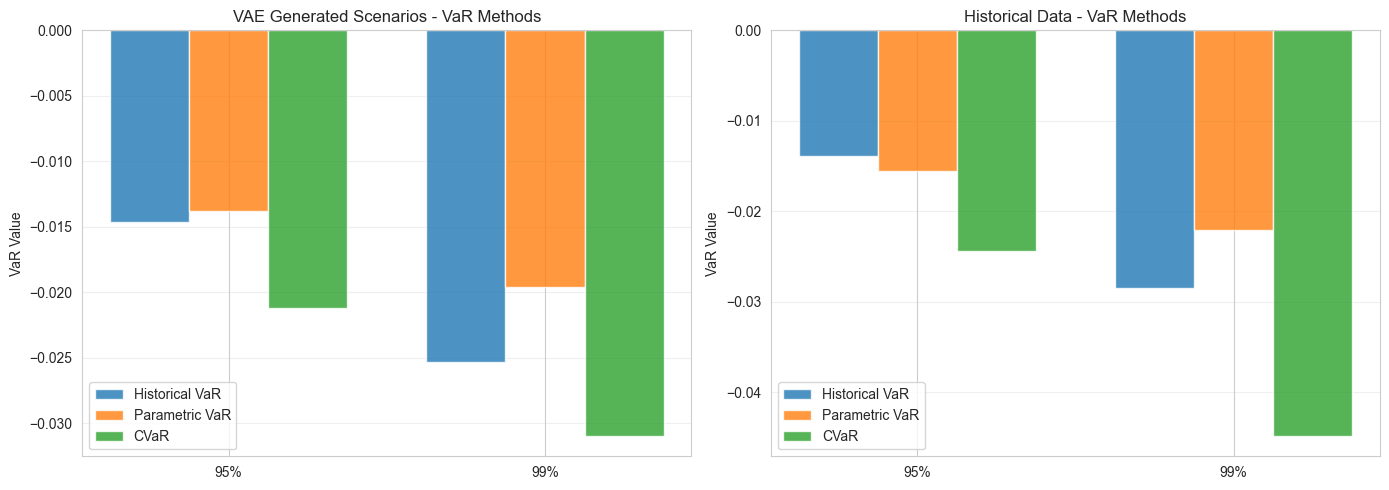

In [7]:
# Plot VaR methods comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Generated scenarios
x = np.arange(len(var_summary_generated))
width = 0.25

axes[0].bar(x - width, var_summary_generated['Historical VaR'], width, label='Historical VaR', alpha=0.8)
axes[0].bar(x, var_summary_generated['Parametric VaR'], width, label='Parametric VaR', alpha=0.8)
axes[0].bar(x + width, var_summary_generated['CVaR'], width, label='CVaR', alpha=0.8)

axes[0].set_title('VAE Generated Scenarios - VaR Methods')
axes[0].set_ylabel('VaR Value')
axes[0].set_xticks(x)
axes[0].set_xticklabels(var_summary_generated['Confidence Level'])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0, color='black', linewidth=0.5)

# Historical data
axes[1].bar(x - width, var_summary_historical['Historical VaR'], width, label='Historical VaR', alpha=0.8)
axes[1].bar(x, var_summary_historical['Parametric VaR'], width, label='Parametric VaR', alpha=0.8)
axes[1].bar(x + width, var_summary_historical['CVaR'], width, label='CVaR', alpha=0.8)

axes[1].set_title('Historical Data - VaR Methods')
axes[1].set_ylabel('VaR Value')
axes[1].set_xticks(x)
axes[1].set_xticklabels(var_summary_historical['Confidence Level'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/07_var_methods_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Risk Metrics Summary

In [8]:
# Calculate additional risk metrics
from scipy import stats

metrics = {
    'Metric': [
        'Mean Return',
        'Std Deviation',
        'Skewness',
        'Kurtosis',
        'Min Return',
        'Max Return',
        'Sharpe Ratio (annual)'
    ],
    'Generated Scenarios': [
        generated_portfolio.mean(),
        generated_portfolio.std(),
        pd.Series(generated_portfolio).skew(),
        pd.Series(generated_portfolio).kurtosis(),
        generated_portfolio.min(),
        generated_portfolio.max(),
        (generated_portfolio.mean() / generated_portfolio.std() * np.sqrt(252))
    ],
    'Historical Data': [
        historical_portfolio_calc.mean(),
        historical_portfolio_calc.std(),
        pd.Series(historical_portfolio_calc).skew(),
        pd.Series(historical_portfolio_calc).kurtosis(),
        historical_portfolio_calc.min(),
        historical_portfolio_calc.max(),
        (historical_portfolio_calc.mean() / historical_portfolio_calc.std() * np.sqrt(252))
    ]
}

metrics_df = pd.DataFrame(metrics)

print("\n" + "="*80)
print("PORTFOLIO RISK METRICS SUMMARY")
print("="*80)
print(metrics_df.to_string(index=False))


PORTFOLIO RISK METRICS SUMMARY
               Metric  Generated Scenarios  Historical Data
          Mean Return             0.000159         0.000263
        Std Deviation             0.008494         0.009605
             Skewness            -0.401573        -0.626001
             Kurtosis             2.685393        13.354299
           Min Return            -0.052014        -0.089540
           Max Return             0.048012         0.085884
Sharpe Ratio (annual)             0.297166         0.435436


## 7. Risk Profiles Visualization

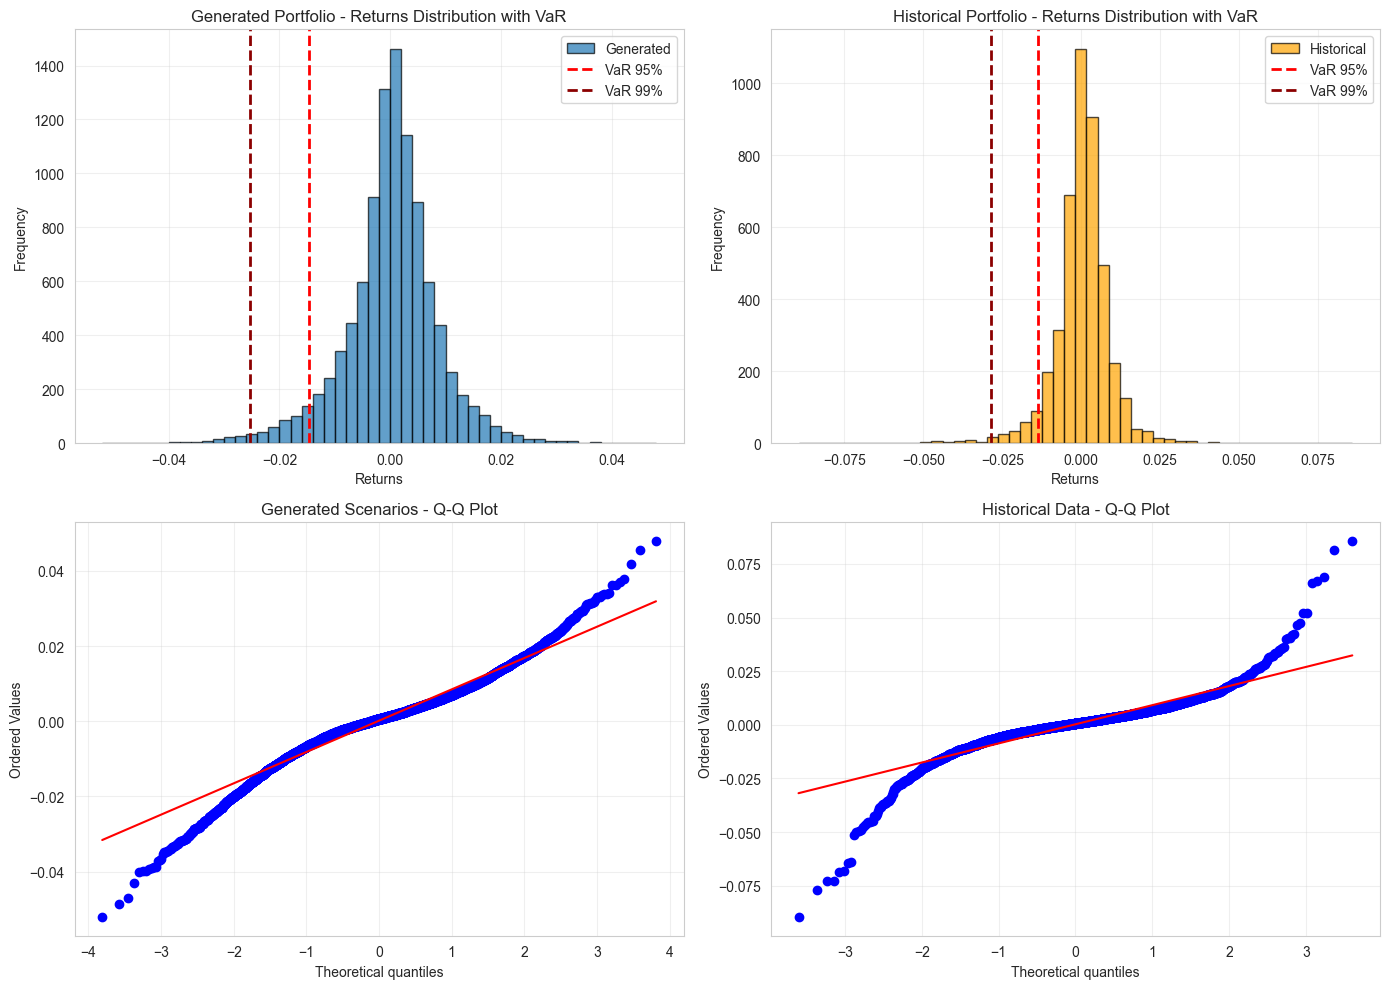

In [9]:
# Risk profile plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Returns distribution with VaR lines
axes[0, 0].hist(generated_portfolio, bins=50, alpha=0.7, label='Generated', edgecolor='black')
axes[0, 0].axvline(var_calc_generated.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
axes[0, 0].axvline(var_calc_generated.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
axes[0, 0].set_title('Generated Portfolio - Returns Distribution with VaR')
axes[0, 0].set_xlabel('Returns')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Historical returns distribution with VaR lines
axes[0, 1].hist(historical_portfolio_calc, bins=50, alpha=0.7, label='Historical', edgecolor='black', color='orange')
axes[0, 1].axvline(var_calc_historical.historical_var(0.95), color='red', linestyle='--', linewidth=2, label='VaR 95%')
axes[0, 1].axvline(var_calc_historical.historical_var(0.99), color='darkred', linestyle='--', linewidth=2, label='VaR 99%')
axes[0, 1].set_title('Historical Portfolio - Returns Distribution with VaR')
axes[0, 1].set_xlabel('Returns')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plots
stats.probplot(generated_portfolio, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Generated Scenarios - Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

stats.probplot(historical_portfolio_calc, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Historical Data - Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/08_risk_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Results

In [10]:
# Save all results
var_summary_generated.to_csv('../results/var_generated_scenarios.csv', index=False)
var_summary_historical.to_csv('../results/var_historical.csv', index=False)
metrics_df.to_csv('../results/risk_metrics.csv', index=False)

print("\n" + "="*80)
print("RESULTS SAVED")
print("="*80)
print("\nFiles saved in ../results/:")
print("  ✓ var_generated_scenarios.csv")
print("  ✓ var_historical.csv")
print("  ✓ risk_metrics.csv")
print("  ✓ 07_var_methods_comparison.png")
print("  ✓ 08_risk_profiles.png")
print("\n🎉 VAE Portfolio Project Completed Successfully!")


RESULTS SAVED

Files saved in ../results/:
  ✓ var_generated_scenarios.csv
  ✓ var_historical.csv
  ✓ risk_metrics.csv
  ✓ 07_var_methods_comparison.png
  ✓ 08_risk_profiles.png

🎉 VAE Portfolio Project Completed Successfully!
